In [1]:
import polars as pd

data = pd.read_csv("data/data.csv")

print(data.columns)

# Average of "Bottom Flywheel Measured Velocity" and "Top Flywheel Measured Velocity"
flywheel_vel = (data["Bottom Flywheel Measured Velocity"] + data["Top Flywheel Measured Velocity"]) / 2
# Total of "Bottom Flywheel Current" and "Top Flywheel Current"
flywheel_current = data["Bottom Flywheel Current"] + data["Top Flywheel Current"]

azimuth_vel = data["Azimuth Measured Velocity"]
azimuth_current = data["Azimuth Current"]

hood_vel = data["Hood Measured Velocity"]
hood_current = data["Hood Current"]

total_current = flywheel_current + azimuth_current + hood_current

['Top Flywheel Target Velocity', 'Top Flywheel Measured Velocity', 'Top Flywheel Current', 'Bottom Flywheel Target Velocity', 'Bottom Flywheel Measured Velocity', 'Bottom Flywheel Current', 'Azimuth Target Velocity', 'Azimuth Measured Velocity', 'Azimuth Current', 'Hood Target Velocity', 'Hood Measured Velocity', 'Hood Current', '']


In [ ]:
%pip install matplotlib "nbformat>=4.2.0"

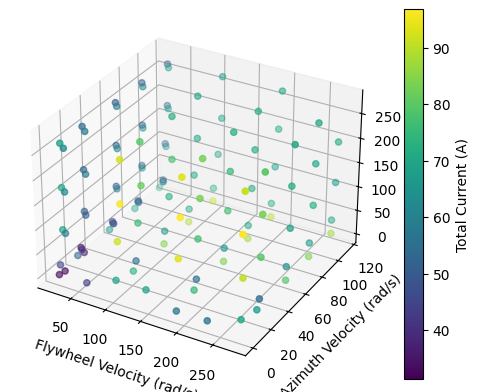

In [2]:
# Plot in 3D with velocities on each axis and current as the color
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=total_current, cmap="viridis")
ax.set_xlabel("Flywheel Velocity (rad/s)")
ax.set_ylabel("Azimuth Velocity (rad/s)")
ax.set_zlabel("Hood Velocity (rad/s)")
fig.colorbar(scat, label="Total Current (A)")
plt.show()

In [3]:
# Interactive plot with the ability to rotate and zoom
import plotly.express as px

fig = px.scatter_3d(
    x=flywheel_vel,
    y=azimuth_vel,
    z=hood_vel,
    color=total_current,
    labels={
        "x": "Flywheel Velocity (rad/s)",
        "y": "Azimuth Velocity (rad/s)",
        "z": "Hood Velocity (rad/s)",
        "color": "Total Current (A)",
        "hover_data": "Current (A)",
    },
    # Individual currents
    hover_data={
        "Flywheel Current (A)": flywheel_current,
        "Azimuth Current (A)": azimuth_current,
        "Hood Current (A)": hood_current,
    },
    title="Turret Motor Velocities and Currents"
)
fig.show()

In [ ]:
# Fit a 4D surface to the data (flywheel_vel, azimuth_vel, hood_vel) -> total_current

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = pd.DataFrame({
    "flywheel_vel": flywheel_vel,
    "azimuth_vel": azimuth_vel,
    "hood_vel": hood_vel
})

y = total_current
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

print("Model coefficients:", model.coef_)

Model coefficients: [ 0.          0.08876288 -0.01374774  0.0301764 ]


In [25]:
# Compute R^2 score for the model
from sklearn.metrics import r2_score
y_pred = model.predict(X_poly)
r2 = r2_score(y, y_pred)
print("R^2 score:", r2)

R^2 score: 0.3699292792203204


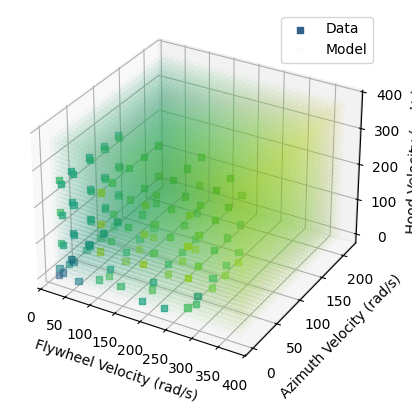

In [26]:
# Predict total current for a grid of velocities
import numpy as np
flywheel_vel_grid = np.linspace(flywheel_vel.min(), flywheel_vel.max() + 100, 32)
azimuth_vel_grid = np.linspace(azimuth_vel.min(), azimuth_vel.max() + 100, 32)
hood_vel_grid = np.linspace(hood_vel.min(), hood_vel.max() + 100, 32)

flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid = np.meshgrid(flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid)

X_grid = pd.DataFrame({
    "flywheel_vel": flywheel_vel_grid.flatten(),
    "azimuth_vel": azimuth_vel_grid.flatten(),
    "hood_vel": hood_vel_grid.flatten(),
})

X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

# Plot the predicted surface
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
# Squares to represent real data and circles to represent the model
vmin = 0
vmax = 100
scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=total_current, cmap="viridis", label="Data", marker="s", vmin=vmin, vmax=vmax)
ax.scatter(X_grid["flywheel_vel"], X_grid["azimuth_vel"], X_grid["hood_vel"], c=y_grid_pred, cmap="viridis", label="Model", marker="o", vmin=vmin, vmax=vmax, alpha=0.02)

ax.set_xlabel("Flywheel Velocity (rad/s)")
ax.set_ylabel("Azimuth Velocity (rad/s)")
ax.set_zlabel("Hood Velocity (rad/s)")
ax.legend()
plt.show()




# 2D cross-section (flywheel vs azimuth) with a slider for hood velocity
import numpy as np
import plotly.graph_objects as go

# flattened grid arrays and predictions (already exist in the notebook)
fx = flywheel_vel_grid.flatten()
ax = azimuth_vel_grid.flatten()
hx = hood_vel_grid.flatten()
pred = y_grid_pred

# unique hood levels (slider steps)
hood_levels = np.unique(hx)

# build one trace per hood slice (only the first visible initially)
pred_traces = []
for i, h in enumerate(hood_levels):
    mask = hx == h
    pred_traces.append(go.Scatter(
        x=fx[mask],
        y=ax[mask],
        mode="markers",
        marker=dict(
            color=pred[mask],
            colorscale="Viridis",
            cmin=vmin,
            cmax=vmax,
            size=6
        ),
        name=f"Model (hood={h:.1f})",
        visible=(i == 0),
        hovertemplate="Flywheel: %{x:.1f}<br>Azimuth: %{y:.1f}<br>Pred: %{marker.color:.2f}<extra></extra>",
    ))

    # Actual data, with opacity scaled by how close the data slice is to our slice
    pred_traces.append(go.Scatter(
        x=flywheel_vel,
        y=azimuth_vel,
        mode="markers",
        marker=dict(
            color=total_current,
            colorscale="Viridis",
            cmin=vmin,
            cmax=vmax,
            size=8,
            opacity=np.exp(-((hood_vel - h) ** 2) / (2 * 20**2))
        ),
        name="Data",
        hovertemplate="Flywheel: %{x:.1f}<br>Azimuth: %{y:.1f}<br>Total Current: %{marker.color:.2f}<extra></extra>",
    ))

fig2d = go.Figure(data=pred_traces)

# slider steps: toggle visibility of the model traces, keep data_trace visible
steps = []
n_model = len(pred_traces)
for i, h in enumerate(hood_levels):
    vis = [False] * n_model
    vis[2 * i] = True  # model trace for this hood slice
    vis[2 * i + 1] = True  # data trace
    steps.append(
        dict(
            method="update",
            args=[{"visible": vis}, {"title": f"Hood slice = {h:3.1f}"}],
            label=f"{h:.0f}",
        )
    )

sliders = [dict(active=0, currentvalue={"prefix": "Hood = "}, pad={"t": 10}, steps=steps)]

fig2d.update_layout(
    title=f"Hood slice = {hood_levels[0]:.1f}",
    xaxis_title="Flywheel Velocity (rad/s)",
    yaxis_title="Azimuth Velocity (rad/s)",
    sliders=sliders,
    height=600,
)

fig2d.show()